In [70]:
# Install dependencies once from the repository root with:
# pip install -r requirements.txt

0

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [72]:
from pathlib import Path

DATA_DIR = Path.cwd().parent / 'data'
if not DATA_DIR.exists():
    DATA_DIR = Path('data')

batsman_data = pd.read_csv(DATA_DIR / 'batsman_2026.csv')
bowler_data = pd.read_csv(DATA_DIR / 'bowler_2026.csv')
matches_data = pd.read_csv(DATA_DIR / 'matches_2026.csv')


In [73]:
matches_data.head()

,match_id,venue,city,team1,team2,toss_winner,toss_decision,winner
0,1527674,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru
1,1527675,"Wankhede Stadium, Mumbai",Mumbai,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,Mumbai Indians
2,1527676,"Barsapara Cricket Stadium, Guwahati",Guwahati,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals
3,1527677,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,Gujarat Titans,Punjab Kings,Punjab Kings,field,Punjab Kings
4,1527678,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,Lucknow Super Giants,Delhi Capitals,Delhi Capitals,field,Delhi Capitals


In [76]:
null_values=matches_data[matches_data['winner'].isna()]
null_values.head()

,match_id,venue,city,team1,team2,toss_winner,toss_decision,winner
11,1527685,"Eden Gardens, Kolkata",Kolkata,Kolkata Knight Riders,Punjab Kings,Kolkata Knight Riders,bat,NaN


In [75]:
matches_data.loc[(matches_data['team1']=='Kolkata Knight Riders')& (matches_data['team2']=='Lucknow Super Giants'),'winner']='Kolkata Knight Riders'

In [5]:
matches_data['Toss_winner_is_match_winner']=(matches_data['toss_winner']==matches_data['winner']).map({True:'Yes',False:'No'})

In [6]:
team_wins=matches_data['winner'].value_counts().reset_index()
team_wins.columns=['Team','Number of wins']
team_wins.head(10)


,Team,Number of wins
0,Royal Challengers Bengaluru,11
1,Gujarat Titans,10
2,Rajasthan Royals,9
3,Sunrisers Hyderabad,9
4,Punjab Kings,7
5,Delhi Capitals,7
6,Chennai Super Kings,6
7,Kolkata Knight Riders,5
8,Mumbai Indians,4
9,Lucknow Super Giants,4


In [7]:
toss_impact=matches_data[matches_data['toss_winner']==matches_data['winner']]
toss_impact.head()


,match_id,venue,city,team1,team2,toss_winner,toss_decision,winner,Toss_winner_is_match_winner
0,1527674,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,Yes
1,1527675,"Wankhede Stadium, Mumbai",Mumbai,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,Yes
2,1527676,"Barsapara Cricket Stadium, Guwahati",Guwahati,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,Yes
3,1527677,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,Gujarat Titans,Punjab Kings,Punjab Kings,field,Punjab Kings,Yes
4,1527678,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,Lucknow Super Giants,Delhi Capitals,Delhi Capitals,field,Delhi Capitals,Yes


In [8]:
toss_decision_results=toss_impact['toss_decision'].value_counts().reset_index(name='Number of wins')

toss_decision_results.head()

,toss_decision,Number of wins
0,field,35
1,bat,2


In [9]:
toss_decision_impact=matches_data['Toss_winner_is_match_winner'].value_counts().reset_index()
toss_decision_impact.head()


,Toss_winner_is_match_winner,count
0,Yes,37
1,No,37


<Axes: xlabel='Toss_winner_is_match_winner', ylabel='toss_decision'>

c:\Users\rajen\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


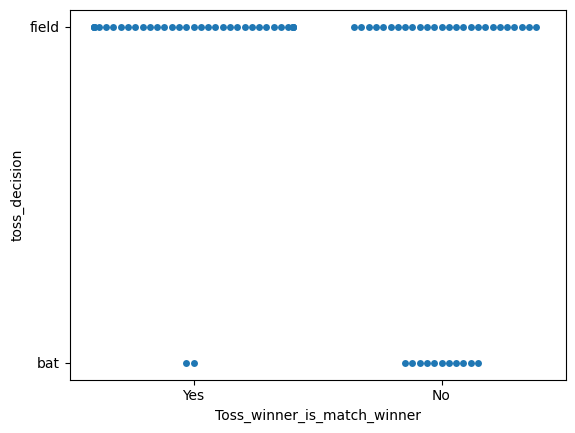

In [10]:
matches_data['Toss_winner_is_match_winner']=(matches_data['toss_winner']==matches_data['winner']).map({True:'Yes',False:'No'})
sns.swarmplot(data=matches_data,x='Toss_winner_is_match_winner',y='toss_decision')

In [11]:
venue_toss_dec=matches_data.groupby('venue')['toss_decision'].value_counts().reset_index()
venue_toss_dec.columns=['Venue','Toss_Decision','Count']
n=len(venue_toss_dec)
venue_toss_dec.head(n)

,Venue,Toss_Decision,Count
0,"Arun Jaitley Stadium, Delhi",field,5
1,"Arun Jaitley Stadium, Delhi",bat,2
2,"Barsapara Cricket Stadium, Guwahati",field,3
3,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,field,7
4,"Eden Gardens, Kolkata",field,5
5,"Eden Gardens, Kolkata",bat,2
6,"Himachal Pradesh Cricket Association Stadium, ...",field,4
7,"M Chinnaswamy Stadium, Bengaluru",field,5
8,"MA Chidambaram Stadium, Chepauk, Chennai",field,5
9,"MA Chidambaram Stadium, Chepauk, Chennai",bat,2


In [12]:
batsman_data.head()

,match_id,batter,batting_team,bowling_team,venue,runs,balls_faced,fours,sixes,strike_rate,is_century,is_fifty,dismissed_player,dismissal_kind
0,1527674,Abhishek Sharma,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",7,11,0,1,63.64,0,0,Abhishek Sharma,caught
1,1527674,Aniket Verma,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",43,18,3,4,238.89,0,0,Aniket Verma,caught
2,1527674,D Padikkal,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",61,26,7,4,234.62,0,1,D Padikkal,caught
3,1527674,DA Payne,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",6,5,0,0,120.00,0,0,NaN,NaN
4,1527674,H Klaasen,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",31,22,2,1,140.91,0,0,H Klaasen,caught


In [13]:
batsman_data['dismissal_kind'].unique()

<StringArray>
[               'caught',                     nan,               'run out',
                'bowled',                   'lbw',     'caught and bowled',
               'stumped',           'retired out',          'retired hurt',
 'obstructing the field',            'hit wicket']
Length: 11, dtype: str

In [14]:
batsman_data['match_no']=batsman_data.groupby('match_id',sort=False).ngroup()+1

In [15]:
batsman_data.head()

,match_id,batter,batting_team,bowling_team,venue,runs,balls_faced,fours,sixes,strike_rate,is_century,is_fifty,dismissed_player,dismissal_kind,match_no
0,1527674,Abhishek Sharma,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",7,11,0,1,63.64,0,0,Abhishek Sharma,caught,1
1,1527674,Aniket Verma,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",43,18,3,4,238.89,0,0,Aniket Verma,caught,1
2,1527674,D Padikkal,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",61,26,7,4,234.62,0,1,D Padikkal,caught,1
3,1527674,DA Payne,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",6,5,0,0,120.00,0,0,NaN,NaN,1
4,1527674,H Klaasen,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",31,22,2,1,140.91,0,0,H Klaasen,caught,1


In [16]:
dismissal_counts=(batsman_data.groupby('match_no')['dismissal_kind'].value_counts().reset_index(name="count"))

In [17]:
dismissal_counts.head()

,match_no,dismissal_kind,count
0,1,caught,13
1,2,caught,7
2,2,run out,1
3,3,caught,5
4,3,bowled,3


In [18]:
#total dismissals per match
total_dpm=(dismissal_counts.groupby("match_no")["count"].sum().reset_index(name="total_dismissals"))

In [19]:
# count for each type of dismissals
diss_type=(dismissal_counts.groupby('dismissal_kind')['count'].sum().reset_index(name='total count'))

In [20]:
total_dpm.head()

,match_no,total_dismissals
0,1,13
1,2,8
2,3,12
3,4,13
4,5,13


<Axes: title={'center': 'Total Dismissals per match'}, xlabel='match_no', ylabel='total_dismissals'>

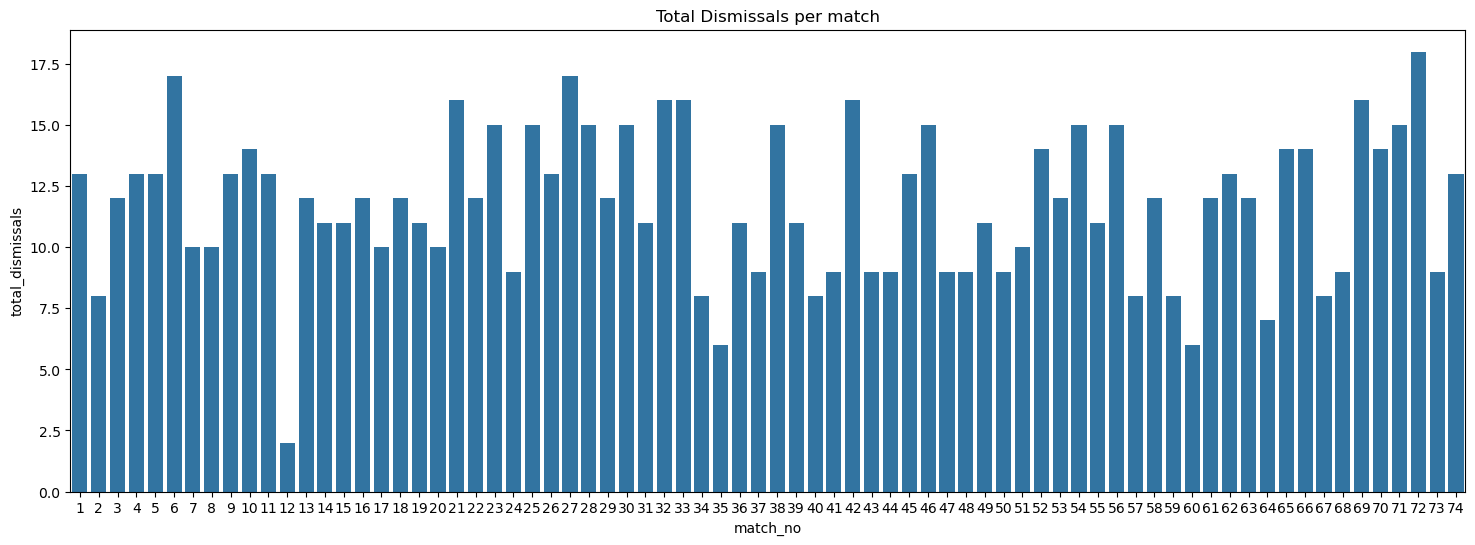

In [21]:
plt.figure(figsize=(18,6))
plt.title('Total Dismissals per match')
sns.barplot(x=total_dpm["match_no"],y=total_dpm["total_dismissals"])



In [22]:
diss_type.head(10)

,dismissal_kind,total count
0,bowled,113
1,caught,649
2,caught and bowled,21
3,hit wicket,2
4,lbw,30
5,obstructing the field,1
6,retired hurt,2
7,retired out,1
8,run out,40
9,stumped,12


<Axes: title={'center': 'Total number of dismissals for each type'}, xlabel='dismissal_kind', ylabel='total count'>

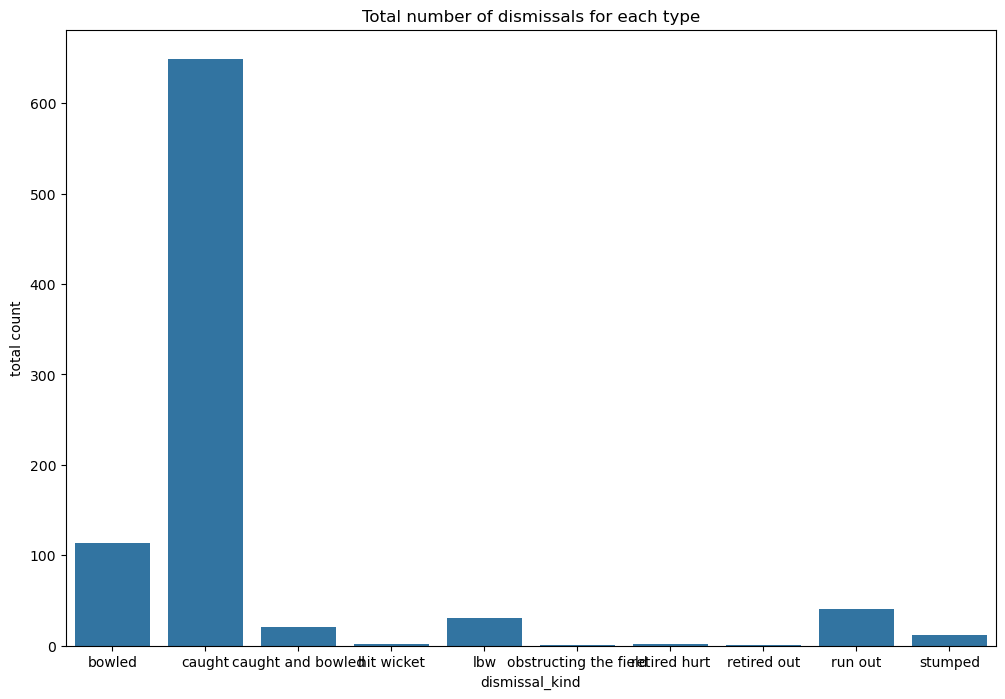

In [23]:
plt.figure(figsize=(12,8))
plt.title('Total number of dismissals for each type')
sns.barplot(x=diss_type['dismissal_kind'],y=diss_type['total count'])

<Figure size 1600x1000 with 0 Axes>

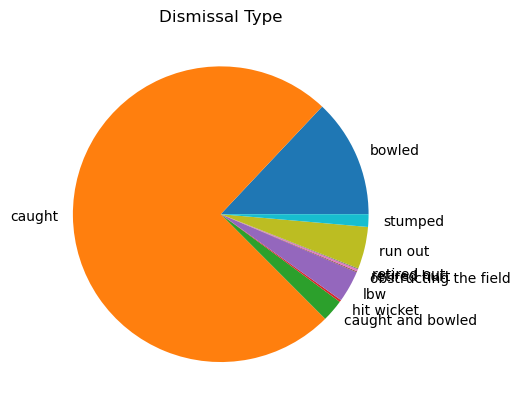

In [24]:
plt.figure(figsize=(16,10))
diss_type.set_index('dismissal_kind').plot.pie(y='total count',legend=False)
plt.title('Dismissal Type')
#plt.legend(loc='upper left')
plt.show()

In [25]:
#centurions
centurions=batsman_data[batsman_data['is_century']==1]


In [26]:
venue_c=centurions.groupby('venue').size().reset_index(name='number_of_centuries')
venue_c.head(15)


,venue,number_of_centuries
0,"Arun Jaitley Stadium, Delhi",2
1,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,2
2,"M Chinnaswamy Stadium, Bengaluru",1
3,"MA Chidambaram Stadium, Chepauk, Chennai",1
4,Maharaja Yadavindra Singh International Cricke...,1
5,"Narendra Modi Stadium, Ahmedabad",1
6,"Rajiv Gandhi International Stadium, Uppal, Hyd...",2
7,"Sawai Mansingh Stadium, Jaipur",1
8,Shaheed Veer Narayan Singh International Stadi...,1
9,"Wankhede Stadium, Mumbai",3


Text(0.5, 0, 'Number of Fifties')

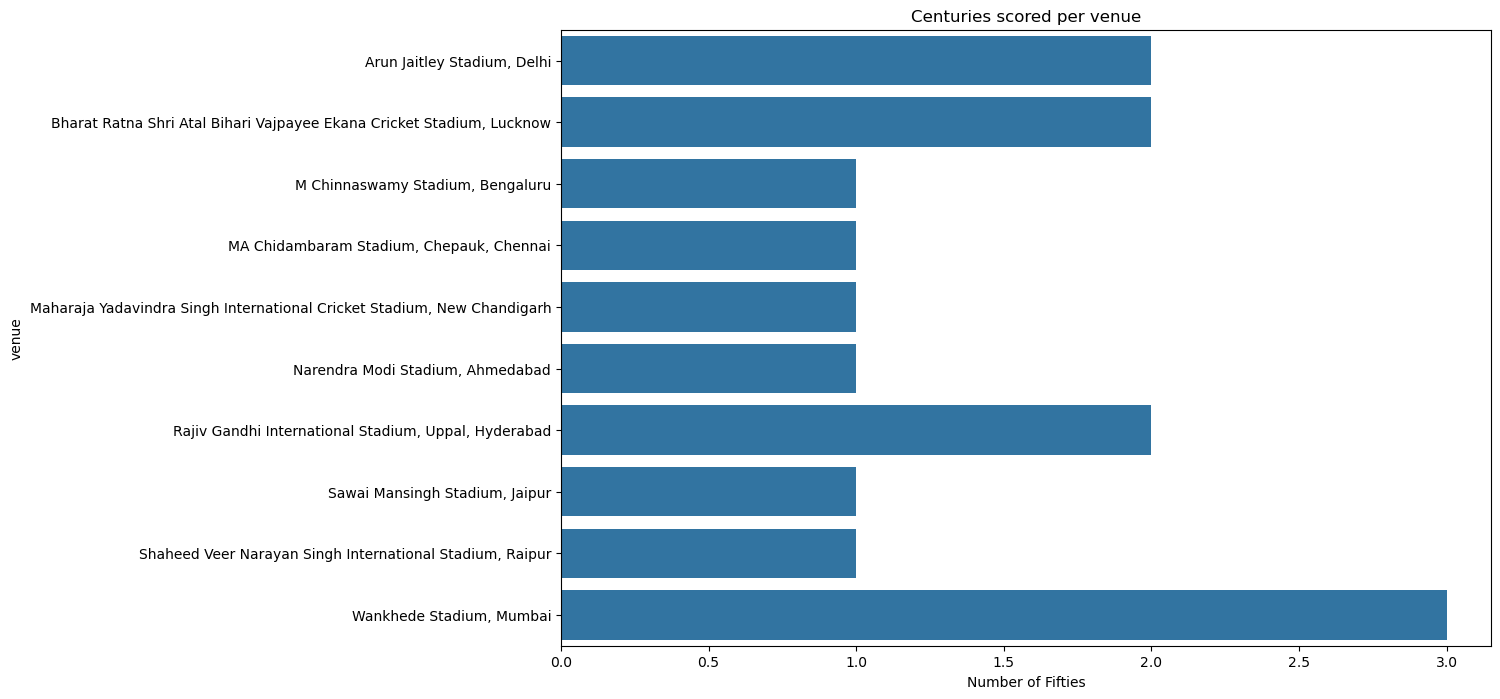

In [27]:
plt.figure(figsize=(12,8))
plt.title('Centuries scored per venue')
sns.barplot(x=venue_c['number_of_centuries'],y=venue_c['venue'],orient='h')
plt.xlabel('Number of Fifties')

In [28]:
#number of centuries
print(f"Total number of centuries :{len(centurions)}")
#number of centurions
print(f"Number of Centurions :{len(centurions['batter'].unique())}")


Total number of centuries :15
Number of Centurions :14


In [29]:
century_counts=(centurions['batter'].value_counts().reset_index(name='Number_of_centuries'))
century_counts.head(15)

,batter,Number_of_centuries
0,SV Samson,2
1,Q de Kock,1
2,Tilak Varma,1
3,Abhishek Sharma,1
4,B Sai Sudharsan,1
5,KL Rahul,1
6,V Suryavanshi,1
7,RD Rickelton,1
8,C Connolly,1
9,MR Marsh,1


In [30]:
half_centurions=batsman_data[batsman_data['is_fifty']==1]
half_centurions.head()

,match_id,batter,batting_team,bowling_team,venue,runs,balls_faced,fours,sixes,strike_rate,is_century,is_fifty,dismissed_player,dismissal_kind,match_no
2,1527674,D Padikkal,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",61,26,7,4,234.62,0,1,D Padikkal,caught,1
7,1527674,Ishan Kishan,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",80,38,8,5,210.53,0,1,Ishan Kishan,caught,1
16,1527674,V Kohli,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",69,40,5,5,172.50,0,1,NaN,NaN,1
17,1527675,A Raghuvanshi,Kolkata Knight Riders,Mumbai Indians,"Wankhede Stadium, Mumbai",51,30,6,2,170.00,0,1,A Raghuvanshi,caught,2
18,1527675,AM Rahane,Kolkata Knight Riders,Mumbai Indians,"Wankhede Stadium, Mumbai",67,43,3,5,155.81,0,1,AM Rahane,caught,2


In [31]:
half_centurions=batsman_data[batsman_data['is_fifty']==1]
half_centurions.head()
#number of half centuries
print(f"Total number of half centuries :{len(half_centurions)}")
#number of fifties
print(f"Total Players who scored a fifty  :{len(half_centurions['batter'].unique())}")
fifties_counts=(half_centurions['batter'].value_counts().reset_index(name='Number_of_fifties'))
fifties_counts.head(15)

Total number of half centuries :154
Total Players who scored a fifty  :60


,batter,Number_of_fifties
0,B Sai Sudharsan,8
1,Ishan Kishan,6
2,H Klaasen,6
3,Dhruv Jurel,6
4,Shubman Gill,6
5,P Simran Singh,6
6,V Kohli,5
7,A Raghuvanshi,5
8,V Suryavanshi,5
9,SS Iyer,5


In [32]:
#venue wise half centuries 
venue_hc=(half_centurions.groupby('venue').size().reset_index(name='no_of_fifties'))
venue_hc=venue_hc.sort_values('no_of_fifties',ascending=False)
print(venue_hc)

                                                venue  no_of_fifties
12                           Wankhede Stadium, Mumbai             17
9   Rajiv Gandhi International Stadium, Uppal, Hyd...             16
7   Maharaja Yadavindra Singh International Cricke...             15
0                         Arun Jaitley Stadium, Delhi             15
8                    Narendra Modi Stadium, Ahmedabad             14
3                               Eden Gardens, Kolkata             13
10                     Sawai Mansingh Stadium, Jaipur             12
6            MA Chidambaram Stadium, Chepauk, Chennai             12
4   Himachal Pradesh Cricket Association Stadium, ...             11
5                    M Chinnaswamy Stadium, Bengaluru             11
2   Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...             10
1                 Barsapara Cricket Stadium, Guwahati              5
11  Shaheed Veer Narayan Singh International Stadi...              3


Text(0.5, 0, 'Number of Fifties')

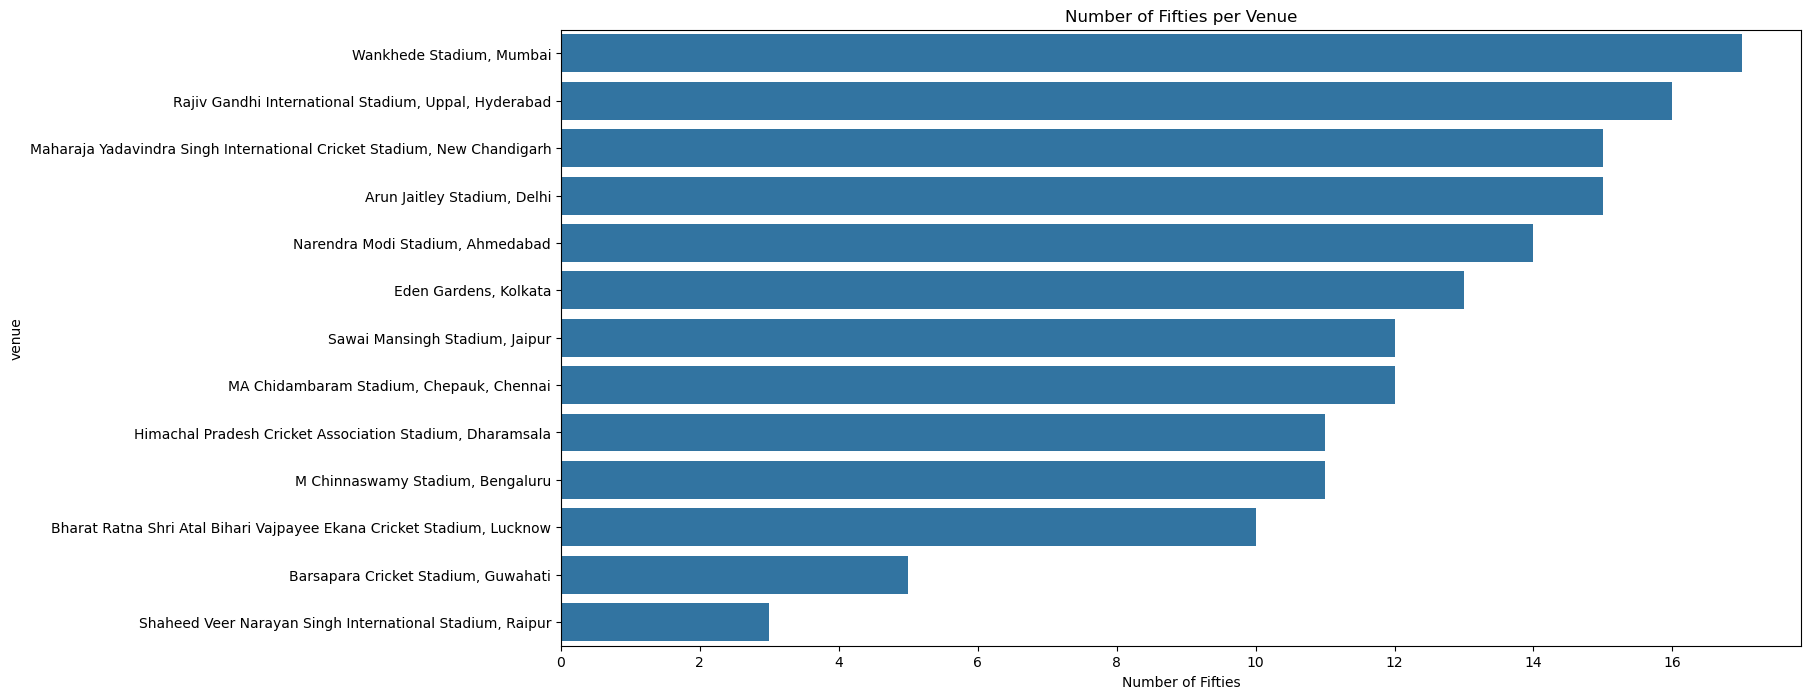

In [33]:
plt.figure(figsize=(16,8))
plt.title('Number of Fifties per Venue',fontsize=12)
sns.barplot(y=venue_hc['venue'],x=venue_hc['no_of_fifties'],orient='h')
plt.xlabel('Number of Fifties')
#plt.xticks(rotation=45, ha='right')  # Rotate 45 degrees
#plt.xticks(rotation=90)
#plt.tight_layout()

In [34]:
batsman_runs=(batsman_data.groupby('batter')['runs'].sum().reset_index(name='Total_Runs_Scored'))
batsman_runs=batsman_runs.sort_values('Total_Runs_Scored',ascending=False)
batsman_runs.head()

,batter,Total_Runs_Scored
167,V Suryavanshi,776
153,Shubman Gill,732
28,B Sai Sudharsan,722
165,V Kohli,675
47,H Klaasen,624


In [35]:
balls_faced=batsman_data.groupby('batter')['balls_faced'].sum().reset_index(name='Balls_faced')
balls_faced=balls_faced.sort_values('Balls_faced',ascending=False)
balls_faced.head()

,batter,Balls_faced
28,B Sai Sudharsan,481
153,Shubman Gill,472
165,V Kohli,425
47,H Klaasen,413
89,MR Marsh,358


In [36]:
batsman_stats=batsman_data.groupby('batter').agg({'match_id':'nunique','runs':sum,'balls_faced':sum,'fours':sum,'sixes':sum}).reset_index()
batsman_stats.columns=['Batter','Innings_Played','Total_Runs_Scored','Balls_Faced','Fours','Sixes']
batsman_stats['Total Boundaries']=batsman_stats['Fours']+batsman_stats['Sixes']
batsman_stats=batsman_stats.sort_values('Total_Runs_Scored',ascending=False)
batsman_stats.head(10)

,Batter,Innings_Played,Total_Runs_Scored,Balls_Faced,Fours,Sixes,Total Boundaries
167,V Suryavanshi,16,776,344,63,72,135
153,Shubman Gill,16,732,472,74,33,107
28,B Sai Sudharsan,17,722,481,75,30,105
165,V Kohli,16,675,425,73,25,98
47,H Klaasen,15,624,413,48,31,79
53,Ishan Kishan,15,602,342,60,32,92
68,KL Rahul,14,593,355,56,31,87
14,Abhishek Sharma,15,563,304,50,43,93
89,MR Marsh,13,563,358,51,36,87
56,JC Buttler,17,526,352,51,26,77


In [37]:
team_boundaries=batsman_data.groupby('batting_team').agg({'sixes':sum,'fours':sum}).reset_index()
team_boundaries.columns=['Team','Sixes','Fours']
team_boundaries['Total_boundaries_Scored']=team_boundaries['Sixes']+team_boundaries['Fours']
team_boundaries=team_boundaries.sort_values('Total_boundaries_Scored',ascending=False)
team_boundaries.head(10)

,Team,Sixes,Fours,Total_boundaries_Scored
7,Rajasthan Royals,181,257,438
9,Sunrisers Hyderabad,171,255,426
8,Royal Challengers Bengaluru,164,261,425
2,Gujarat Titans,124,292,416
6,Punjab Kings,163,219,382
0,Chennai Super Kings,124,220,344
5,Mumbai Indians,140,204,344
1,Delhi Capitals,117,225,342
4,Lucknow Super Giants,127,209,336
3,Kolkata Knight Riders,115,192,307


<function matplotlib.pyplot.show(close=None, block=None)>

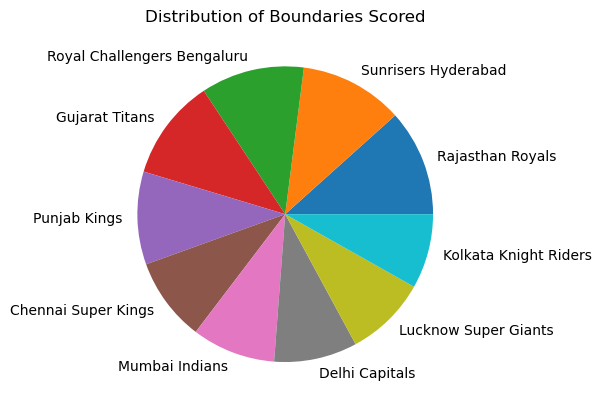

In [38]:
team_boundaries.set_index('Team').plot.pie(y='Total_boundaries_Scored',legend=False)
#plt.legend(loc='upper left')
plt.title('Distribution of Boundaries Scored')
plt.show

In [39]:
team_boundaries_conceded=batsman_data.groupby('bowling_team').agg({'sixes':sum,'fours':sum}).reset_index()
team_boundaries_conceded.columns=['Team','Sixes_Conceded','Fours_Conceded']
team_boundaries_conceded['Total_boundaries_conceded']=team_boundaries_conceded['Sixes_Conceded']+team_boundaries_conceded['Fours_Conceded']
team_boundaries_conceded.head(10)


,Team,Sixes_Conceded,Fours_Conceded,Total_boundaries_conceded
0,Chennai Super Kings,135,201,336
1,Delhi Capitals,150,201,351
2,Gujarat Titans,173,267,440
3,Kolkata Knight Riders,114,210,324
4,Lucknow Super Giants,141,218,359
5,Mumbai Indians,145,222,367
6,Punjab Kings,141,230,371
7,Rajasthan Royals,140,274,414
8,Royal Challengers Bengaluru,142,256,398
9,Sunrisers Hyderabad,145,255,400


In [40]:
team_stats=team_boundaries.merge(team_boundaries_conceded,on='Team')
#matches=batsman_data.groupby('batting_team')['match_id'].nunique().reset_index()
#matches.columns=['Team','Matches_played']
#team_stats=team_stats.merge(matches,on='Team',how='left')
team_stats.head(10)

,Team,Sixes,Fours,Total_boundaries_Scored,Sixes_Conceded,Fours_Conceded,Total_boundaries_conceded
0,Rajasthan Royals,181,257,438,140,274,414
1,Sunrisers Hyderabad,171,255,426,145,255,400
2,Royal Challengers Bengaluru,164,261,425,142,256,398
3,Gujarat Titans,124,292,416,173,267,440
4,Punjab Kings,163,219,382,141,230,371
5,Chennai Super Kings,124,220,344,135,201,336
6,Mumbai Indians,140,204,344,145,222,367
7,Delhi Capitals,117,225,342,150,201,351
8,Lucknow Super Giants,127,209,336,141,218,359
9,Kolkata Knight Riders,115,192,307,114,210,324


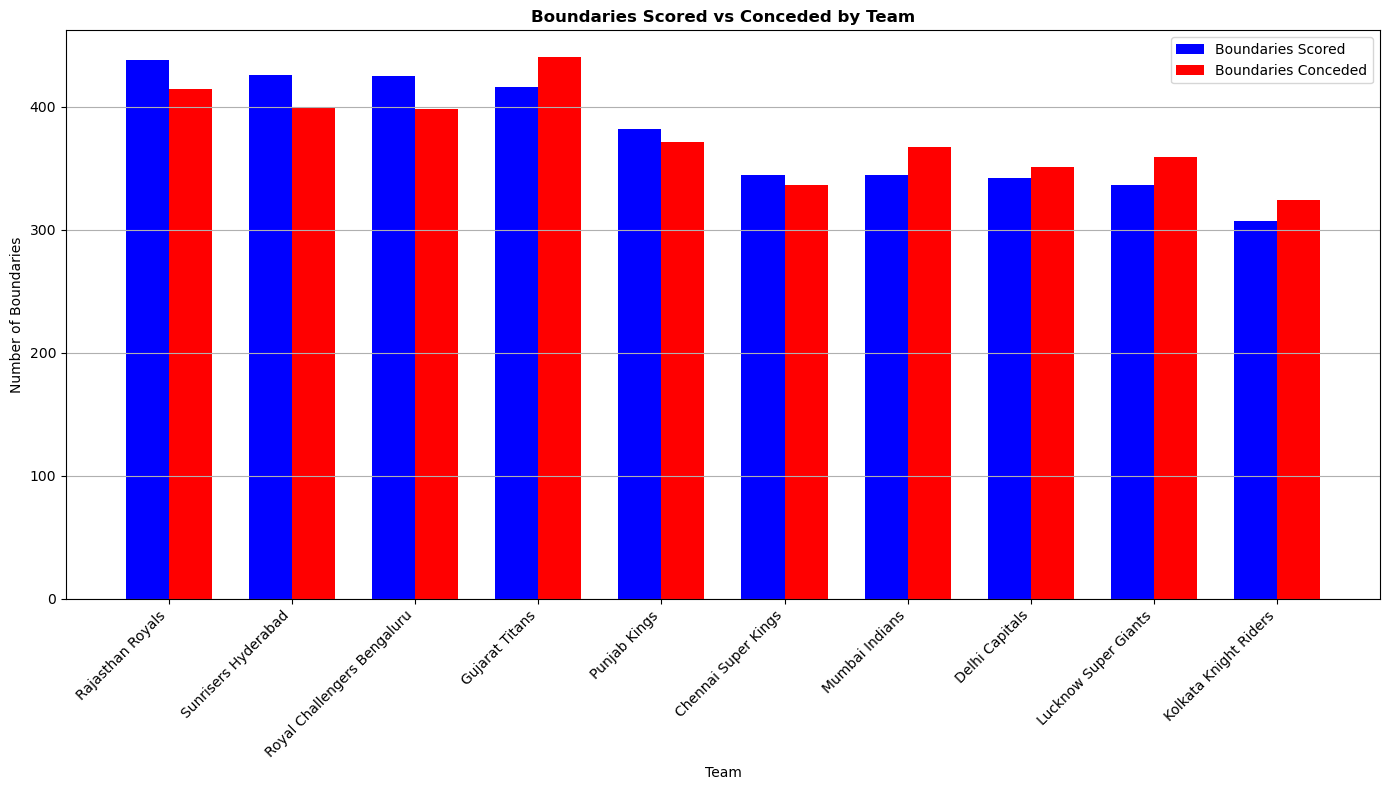

In [41]:
fig,  ax= plt.subplots(figsize=(14, 8))

x = range(len(team_stats))
width = 0.35

ax.bar([i - width/2 for i in x], team_stats['Total_boundaries_Scored'], 
       width, label='Boundaries Scored', color='blue')
ax.bar([i + width/2 for i in x], team_stats['Total_boundaries_conceded'], 
       width, label='Boundaries Conceded', color='red')

ax.set_xlabel('Team')
ax.set_ylabel('Number of Boundaries')
ax.set_title('Boundaries Scored vs Conceded by Team',fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(team_stats['Team'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

C:\Users\rajen\AppData\Local\Temp\ipykernel_12544\1586896633.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


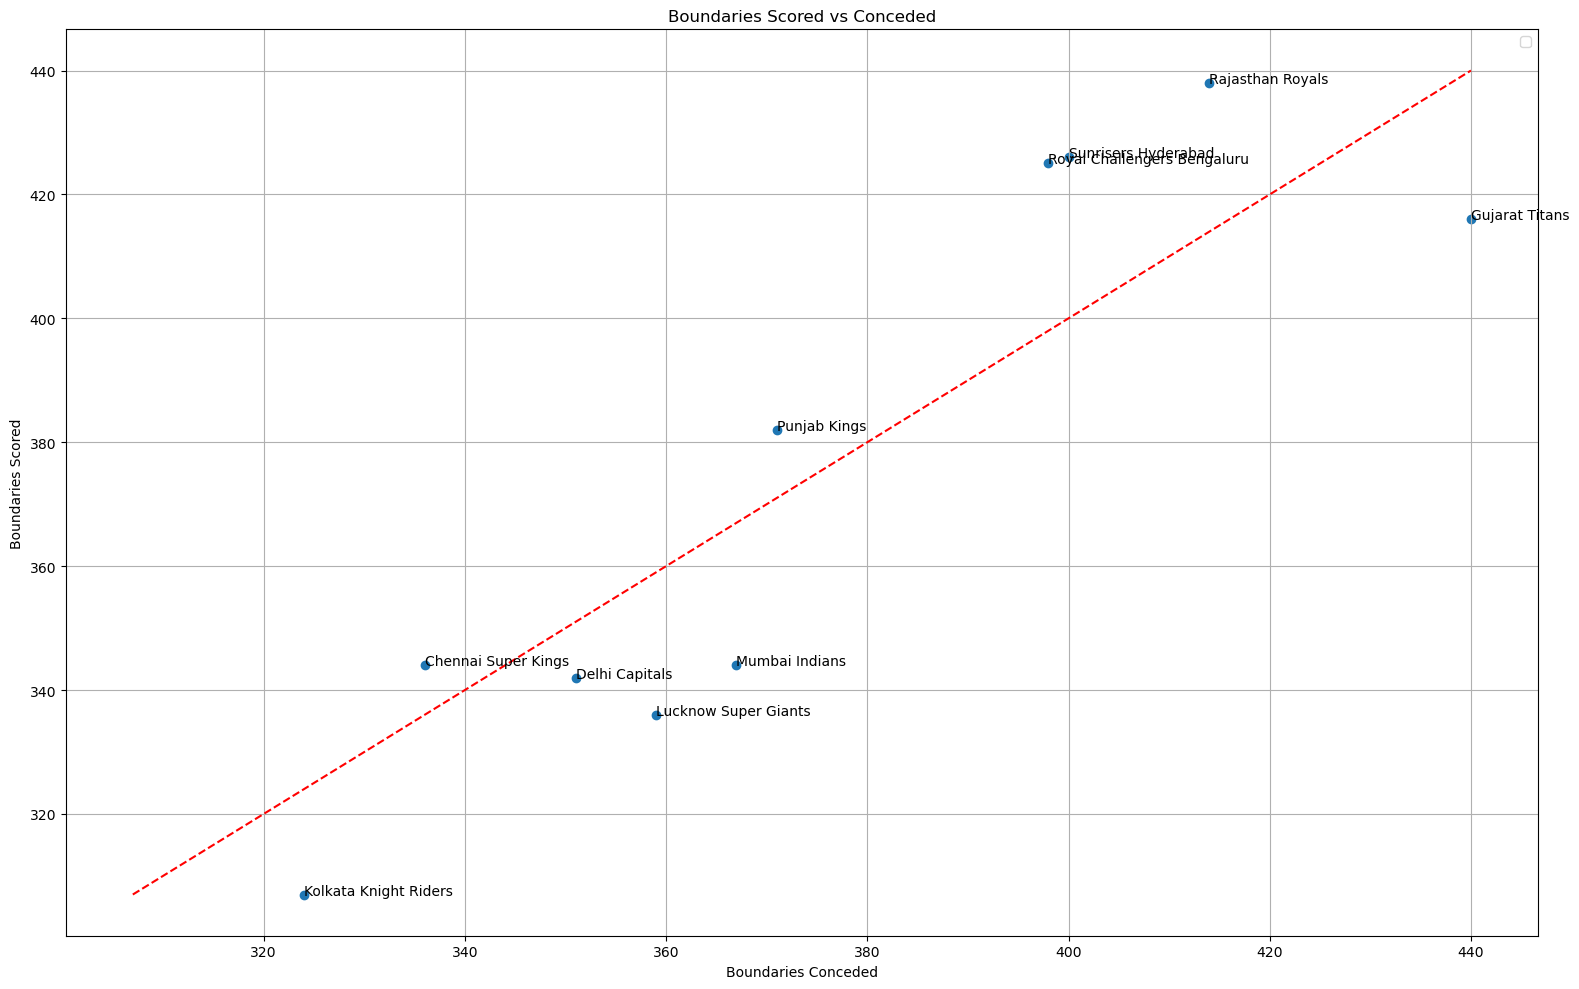

In [42]:
fig, ax=plt.subplots(figsize=(16,10))
ax.scatter(team_stats['Total_boundaries_conceded'],team_stats['Total_boundaries_Scored'])
for idx, row in team_stats.iterrows():
    ax.annotate(row['Team'],
                (row['Total_boundaries_conceded'],row['Total_boundaries_Scored']))

min_val = min(team_stats['Total_boundaries_Scored'].min(), team_stats['Total_boundaries_conceded'].min())
max_val = max(team_stats['Total_boundaries_Scored'].max(), team_stats['Total_boundaries_conceded'].max())
ax.plot([min_val,max_val],[min_val,max_val],'r--')
ax.set_xlabel('Boundaries Conceded')
ax.set_ylabel('Boundaries Scored')
ax.set_title('Boundaries Scored vs Conceded')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
bowler_data.head()

,match_id,bowler,batting_team,bowling_team,venue,wickets,runs,overs,economy,bowling_sr,five_wickets_haul,four_wickets_haul
0,1527674,Abhinandan Singh,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",1,38,3.0,12.67,18.0,0,0
1,1527674,B Kumar,Sunrisers Hyderabad,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",1,33,4.3,7.62,26.0,0,0
2,1527674,DA Payne,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",2,35,3.2,11.05,9.5,0,0
3,1527674,E Malinga,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",0,35,2.7,13.13,NaN,0,0
4,1527674,HV Patel,Royal Challengers Bengaluru,Sunrisers Hyderabad,"M Chinnaswamy Stadium, Bengaluru",0,43,2.8,15.18,NaN,0,0


In [44]:
bowler_stats=bowler_data.groupby('bowler').agg({'wickets':sum,'match_id':'nunique','runs':sum,'economy':'mean'}).reset_index()
bowler_stats.columns=['Bowler','Wickets Taken','Inninga played','Runs Conceded','Economy']

#innings_Played=bowler_data.groupby('bowler')['match_id'].nunique().reset_index(name='Innings_played')
#bowler_stats=bowler_stats.merge(innings_Played,on='bowler')
bowler_stats=bowler_stats.sort_values('Wickets Taken',ascending=False)
bowler_stats.head(10)

,Bowler,Wickets Taken,Inninga played,Runs Conceded,Economy
48,K Rabada,29,17,631,9.610588
21,B Kumar,28,16,504,7.626250
42,JC Archer,25,16,566,8.988750
1,A Kamboj,21,14,535,10.259286
95,Rashid Khan,21,17,527,9.635294
33,E Malinga,20,15,510,8.851333
72,Mohammed Siraj,19,17,570,8.780000
96,Rasikh Salam,19,12,407,8.984167
52,Kartik Tyagi,18,13,504,9.556154
101,SP Narine,17,13,350,6.871538


In [45]:
team_bowling=bowler_data.groupby('bowling_team')['wickets'].sum().reset_index()
team_bowling.columns=['Team','Wickets_Taken']
team_bowling.head()


,Team,Wickets_Taken
0,Chennai Super Kings,76
1,Delhi Capitals,64
2,Gujarat Titans,118
3,Kolkata Knight Riders,83
4,Lucknow Super Giants,67


In [46]:
team_stats=team_stats.merge(team_bowling,on='Team',how='left')
team_stats.head()

,Team,Sixes,Fours,Total_boundaries_Scored,Sixes_Conceded,Fours_Conceded,Total_boundaries_conceded,Wickets_Taken
0,Rajasthan Royals,181,257,438,140,274,414,98
1,Sunrisers Hyderabad,171,255,426,145,255,400,90
2,Royal Challengers Bengaluru,164,261,425,142,256,398,104
3,Gujarat Titans,124,292,416,173,267,440,118
4,Punjab Kings,163,219,382,141,230,371,64


In [47]:
team_batting=bowler_data.groupby('batting_team')['wickets'].sum().reset_index()
team_batting.columns=['Team','Wickets_given']
team_stats=team_stats.merge(team_batting,on='Team')
team_stats.head(10)

,Team,Sixes,Fours,Total_boundaries_Scored,Sixes_Conceded,Fours_Conceded,Total_boundaries_conceded,Wickets_Taken,Wickets_given
0,Rajasthan Royals,181,257,438,140,274,414,98,94
1,Sunrisers Hyderabad,171,255,426,145,255,400,90,97
2,Royal Challengers Bengaluru,164,261,425,142,256,398,104,82
3,Gujarat Titans,124,292,416,173,267,440,118,89
4,Punjab Kings,163,219,382,141,230,371,64,72
5,Chennai Super Kings,124,220,344,135,201,336,76,81
6,Mumbai Indians,140,204,344,145,222,367,73,85
7,Delhi Capitals,117,225,342,150,201,351,64,80
8,Lucknow Super Giants,127,209,336,141,218,359,67,87
9,Kolkata Knight Riders,115,192,307,114,210,324,83,70


In [48]:
fivew_hauls=bowler_data[bowler_data['five_wickets_haul']==1]
fivew_hauls.head()

,match_id,bowler,batting_team,bowling_team,venue,wickets,runs,overs,economy,bowling_sr,five_wickets_haul,four_wickets_haul
436,1529281,Mohsin Khan,Kolkata Knight Riders,Lucknow Super Giants,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,5,24,4.2,5.76,5.0,1,0


In [49]:
fourw_hauls=bowler_data[bowler_data['four_wickets_haul']==1]
print(f"Number of 4 wicket hauls:{len('fourw_hauls')}")
fourw_hauls.head(11)


Number of 4 wicket hauls:11


,match_id,bowler,batting_team,bowling_team,venue,wickets,runs,overs,economy,bowling_sr,five_wickets_haul,four_wickets_haul
62,1527679,B Muzarabani,Sunrisers Hyderabad,Kolkata Knight Riders,"Eden Gardens, Kolkata",4,45,4.3,10.38,6.50,0,1
105,1527682,Ravi Bishnoi,Gujarat Titans,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",4,41,4.2,9.84,6.25,0,1
197,1527691,J Overton,Delhi Capitals,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk, Chennai",4,19,4.3,4.38,6.50,0,1
210,1527692,M Prasidh Krishna,Lucknow Super Giants,Gujarat Titans,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,4,28,4.0,7.00,6.00,0,1
232,1529264,PP Hinge,Rajasthan Royals,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",4,34,4.3,7.85,6.50,0,1
235,1529264,Sakib Hussain,Rajasthan Royals,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",4,24,4.5,5.33,6.75,0,1
259,1529266,Rasikh Salam,Lucknow Super Giants,Royal Challengers Bengaluru,"M Chinnaswamy Stadium, Bengaluru",4,25,4.0,6.25,6.00,0,1
334,1529273,Ashwani Kumar,Gujarat Titans,Mumbai Indians,"Narendra Modi Stadium, Ahmedabad",4,24,4.3,5.54,6.50,0,1
346,1529274,E Malinga,Delhi Capitals,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",4,32,4.3,7.38,6.50,0,1
367,1529276,AJ Hosein,Mumbai Indians,Chennai Super Kings,"Wankhede Stadium, Mumbai",4,17,4.0,4.25,6.00,0,1


In [50]:
bowlers_fourw=fourw_hauls['bowler'].value_counts().reset_index(name='Number of 4 wicket hauls')
bowlers_fourw.head(11)

,bowler,Number of 4 wicket hauls
0,B Muzarabani,1
1,Ravi Bishnoi,1
2,J Overton,1
3,M Prasidh Krishna,1
4,PP Hinge,1
5,Sakib Hussain,1
6,Rasikh Salam,1
7,Ashwani Kumar,1
8,E Malinga,1
9,AJ Hosein,1
